## Table of Contents

1. [Modeling Objective](#objective)
- Define modeling goals and transformation choices

2. [Dataset Setup](#data)
- Describe full vs trimmed datasets and feature selection

3. [Train/Test Split Strategy](#split)
- Explain consistent splitting approach across models

4. [Model Evaluation Function](#function)
- Standardize model fitting and performance evaluation

5. [Initial Model Search](#full-model)
- Establish baseline model on full dataset

6. [Trimmed Model Specifications](#trimmed-models)
- Evaluate refined models on trimmed dataset  
  - [Baseline (Trimmed)](#trimmed-baseline)  
  - [Nonlinear Age](#nonlinear-age)  
  - [Drop Bathrooms](#drop-bathrooms)  
  - [Drop Grade (Stress Test)](#drop-grade)

7. [Model Comparison](#comparison)
- Compare performance across specifications

8. [Final Model Selection](#selection)
- Select final model based on performance and parsimony

9. [Additional Model Exploration](#additional)
- Evaluate stepwise regression and one-hot encoding

10. [Inference and Diagnostics](#inference)
- Assess statistical significance and multicollinearity

11. [Final Model Equation](#equation)
- Present model structure and coefficient interpretation

12. [Target Variable Comparison](#target)
- Compare log(price) vs price models

13. [Residual Interpretation](#residuals)
- Evaluate model errors and prediction behavior

14. [Conclusion](#conclusion)
- Summarize findings and modeling decisions

## Modeling Objective
<a id="objective"></a>

The goal of this phase is to develop a rigorous and interpretable linear regression workflow for predicting housing prices.

Based on prior preprocessing and exploratory analysis, price was found to be strongly right-skewed. A log transformation is therefore applied to improve linearity, stabilize variance, and better satisfy regression assumptions.

Model development followed an iterative process in which numerous candidate specifications were evaluated. Models were compared primarily using out-of-sample performance, with Root Mean Squared Error (RMSE) as the main selection criterion and R² included for additional context. Although models are estimated using a log-transformed target, final predictions are converted back to the original price scale for evaluation. RMSE was prioritized because it measures prediction error in dollar terms (USD), making differences in model performance directly interpretable in practical terms.

Ordinary Least Squares (OLS) estimation was used throughout the process to assess coefficient behavior and statistical significance. While multiple OLS outputs were reviewed during development, only the final model summary is presented here to maintain clarity and reduce unnecessary redundancy.

A broader set of models was explored during development; however, only a subset is presented in this notebook to maintain a clear and focused narrative. These retained models represent the key stages of refinement leading to the final specification.

This notebook focuses on:

* constructing an initial linear model using `log_price` as the target
* refining predictor selection based on theory, redundancy, and predictive performance
* comparing model behavior across full and trimmed datasets
* evaluating models using consistent train/test splits
* selecting a final specification for inference, diagnostics, and interpretation

The objective is not only to maximize predictive accuracy, but also to produce a stable and interpretable model aligned with the underlying structure of the data.


In [98]:
# --------------------------------------------------
# Core Libraries
# --------------------------------------------------
import pandas as pd
import numpy as np

# Visualization (used in diagnostics)
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

# Statistical modeling (inference + VIF)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', None)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

### Dataset Setup
<a id="data"></a>

Two modeling datasets are used throughout this analysis:

- `outliers_df`: feature-engineered dataset including extreme observations  
- `trimmed_df`: feature-engineered dataset with extreme outliers removed using the previously defined 3×IQR rule  

While the original dataset contains a larger number of variables, only a subset of engineered predictors is included here to avoid redundancy (e.g., logged vs. non-logged versions of the same feature) and maintain a consistent modeling structure.

The full dataset is used initially for model specification, while the trimmed dataset is used to assess the impact of extreme observations on model performance and stability. This allows for a direct comparison to determine whether excluding outliers leads to more reliable and generalizable results.

In [99]:
# --------------------------------------------------
# Load Modeling Datasets
# --------------------------------------------------

outliers_df = pd.read_csv("cleaned_house_sales_with_outliers.csv")
trimmed_df = pd.read_csv("cleaned_house_sales.csv")

print("With outliers shape:", outliers_df.shape)
print("Without outliers shape:", trimmed_df.shape)

With outliers shape: (21613, 29)
Without outliers shape: (21096, 29)


### Train/Test Split Strategy
<a id="split"></a>

To ensure fair comparison across model specifications, train/test splits
are defined using fixed row indices rather than re-splitting each model
separately.

This approach keeps the evaluation sample constant while allowing
predictor sets to vary across model specifications.

In [100]:
# --------------------------------------------------
# Train/Test Split Strategy
# --------------------------------------------------

# Define fixed train/test indices to ensure consistent evaluation
train_idx, test_idx = train_test_split(
    outliers_df.index,
    test_size=0.2,
    random_state=42
)

train_idx_trim, test_idx_trim = train_test_split(
    trimmed_df.index,
    test_size=0.2,
    random_state=42
)

print(f"Training rows (full dataset): {len(train_idx):,}")
print(f"Test rows (full dataset): {len(test_idx):,}")

print(f"Training rows (trimmed dataset): {len(train_idx_trim):,}")
print(f"Test rows (trimmed dataset): {len(test_idx_trim):,}")

Training rows (full dataset): 17,290
Test rows (full dataset): 4,323
Training rows (trimmed dataset): 16,876
Test rows (trimmed dataset): 4,220


### Model Evaluation Helper Function
<a id="function"></a>

A helper function is defined to standardize model estimation and
evaluation across specifications.

It applies fixed train/test splits, fits a linear regression model, and
returns key performance metrics and outputs for comparison and
diagnostics.

In [101]:
# --------------------------------------------------
# Define helper function for model estimation
# --------------------------------------------------

def run_model(
    df,
    dataset_name,
    target,
    predictors,
    train_idx,
    test_idx,
    model_name
):
    """
    Fit a linear regression model and return in-sample and
    out-of-sample metrics.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing target and predictor variables.
    dataset_name : str
        Label identifying which dataset is being used.
    target : str
        Name of dependent variable column.
    predictors : list[str]
        List of predictor column names.
    train_idx : pandas.Index or array-like
        Row indices for the training set.
    test_idx : pandas.Index or array-like
        Row indices for the test set.
    model_name : str
        Label used to identify the model in comparison output.

    Returns
    -------
    dict
        Dictionary containing model metadata, fitted model, and
        performance metrics.
    """
    # Define predictor matrix and target vector
    X = df[predictors]
    y = df[target]

    # Apply fixed train/test split using row indices
    X_train = X.loc[train_idx]
    X_test = X.loc[test_idx]
    y_train = y.loc[train_idx]
    y_test = y.loc[test_idx]

    # Fit linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Generate predictions for both training and test sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate in-sample metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)

    # Calculate out-of-sample metrics
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)

    # Return results in dictionary form for later comparison
    return {
        "Dataset": dataset_name,
        "Model": model_name,
        "Target": target,
        "Num_Predictors": len(predictors),
        "Predictors": predictors,
        "Train_RMSE": train_rmse,
        "Test_RMSE": test_rmse,
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Fitted_Model": model,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_train_pred": y_train_pred,
        "y_test_pred": y_test_pred
    }

### Initial Model Search on Full Dataset
<a id="full-model"></a>

Model development began on the full dataset in order to evaluate predictor structure under the most challenging conditions, including extreme observations. This phase was used to test:

* target transformation choice
* structural representation of living area
* redundancy among housing attributes
* whether the model remained stable under outlier-influenced conditions

For modeling purposes, the “full dataset” refers to the complete feature-engineered dataset prior to outlier removal. While this dataset contains a larger number of variables, only a subset of predictors is used in the initial model specification.

Predictor selection was guided by a combination of statistical reasoning and practical modeling considerations:

* **Variable type:** Only numerical and ordinal predictors were included in the initial specification. Categorical groupings and engineered bin variables were excluded to maintain a consistent linear modeling framework.

* **Feature engineering choices:** Log transformations were applied to continuous variables exhibiting strong right-skew, improving linearity and allowing the model to capture proportional relationships between predictors and price.

* **Derived neighborhood features:** Precomputed neighborhood-based variables (e.g., nearest-neighbor averages) were excluded to avoid introducing implicit spatial aggregation effects and redundancy with individual property-level features.

The initial specification intentionally includes a broad set of candidate predictors, allowing subsequent model refinement to evaluate redundancy, statistical contribution, and predictive impact.

This structured approach ensures that the initial model reflects a comprehensive starting point while avoiding unnecessary complexity before refinement.

In [102]:
# --------------------------------------------------
# Baseline Model — Full Dataset (Log Price)
# --------------------------------------------------

spec_baseline_full = {
    "model_name": "Baseline Full (Log)",
    "df": outliers_df,
    "target": "log_price",
    "predictors": [
        "bedrooms",
        "floors",
        "log_sqft_above",
        "log_sqft_basement",
        "bathrooms",
        "grade",
        "condition",
        "sale_month",
        "house_age",
        "renovated_bool",
        "log_sqft_lot",
        "waterfront",
        "view"
    ],
    "train_idx": train_idx,
    "test_idx": test_idx,
    "dataset_name": "Full"
}

### Baseline Model — Trimmed Dataset
<a id="trimmed-models"></a>

A baseline model is estimated on the trimmed dataset to evaluate model performance after removing extreme outliers and to refine predictor selection based on statistical contribution and interpretability.

Variables were removed from the initial specification based on a combination of statistical significance, redundancy, and conceptual alignment:

* **Temporal variable** (`sale_month`): Although statistically significant, this variable was excluded because it does not represent a meaningful ordinal or continuous relationship. Treating month as a numeric feature imposes a linear structure on inherently cyclical seasonal effects, making interpretation less appropriate within a linear regression framework.

* **Renovation indicator** (`renovated_bool`): This variable was removed due to lack of statistical significance, indicating limited contribution once other structural and quality-related features were included.

* **Bedrooms:** Bedroom count was removed after testing showed that its effect was largely absorbed by living area and other structural variables. A negative coefficient indicated redundancy rather than a true inverse relationship, and removing bedrooms had minimal impact on out-of-sample performance, confirming limited incremental predictive value.

* **Living area representation:** The combined variable `log_sqft_living` was selected over its components (`log_sqft_above` and `log_sqft_basement`) after testing showed that including both components increased multicollinearity without improving model performance.

This refinement results in a more parsimonious and interpretable specification while maintaining comparable predictive accuracy.


<a id="trimmed-baseline"></a>

In [103]:
# --------------------------------------------------
# Baseline Model — Trimmed Dataset (Log Price)
# --------------------------------------------------

spec_baseline_trimmed = {
    "model_name": "Baseline Trimmed (Log)",
    "df": trimmed_df,
    "target": "log_price",
    "predictors": [
        "floors",
        "log_sqft_living",
        "bathrooms",
        "grade",
        "condition",
        "house_age",
        "log_sqft_lot",
        "waterfront",
        "view"
    ],
    "train_idx": train_idx_trim,
    "test_idx": test_idx_trim,
    "dataset_name": "Trimmed"
}

### Nonlinear Age Specification — Trimmed Dataset
<a id="nonlinear-age"></a>

Exploratory analysis indicated a nonlinear relationship between house age and price, with price tending to decrease for mid-aged homes before increasing again for older properties. To capture this pattern, `house_age` is centered and a quadratic term is introduced.

Both the linear and squared terms are included to model this non-monotonic relationship. The centered linear term captures the overall trend in price with age, while the squared term allows for curvature, enabling the model to reflect changes in direction across the age distribution.

Centering the age variable reduces structural multicollinearity between the linear and quadratic terms, improving coefficient stability and interpretability without altering the underlying relationship.

The squared age term is scaled by a factor of 100 to improve numerical readability. This transformation preserves the linear relationship and does not affect model fit or statistical inference, but allows the coefficient to be interpreted more clearly without being expressed in very small magnitudes.

In [104]:
# --------------------------------------------------
# Trimmed Dataset — Nonlinear Age Model (Log Price)
# --------------------------------------------------

# Scale the centered squared house age for better coefficient interpetation
trimmed_df["house_age_c_sq"] = trimmed_df["house_age_c_sq"] / 100

spec_nonlinear_age_trimmed = {
    "model_name": "Trimmed + Nonlinear Age (Log)",
    "df": trimmed_df,
    "target": "log_price",
    "predictors": [
        "floors",
        "log_sqft_living",
        "bathrooms",
        "grade",
        "condition",
        "house_age_c",
        "house_age_c_sq",
        "log_sqft_lot",
        "waterfront",
        "view"
    ],
    "train_idx": train_idx_trim,
    "test_idx": test_idx_trim,
    "dataset_name": "Trimmed"
}

### Reduced Model — Drop Bathrooms
<a id="drop-bathrooms"></a>

Bathrooms were removed to evaluate whether they provide meaningful incremental predictive value beyond other structural and quality-related features.

Although `bathrooms` remained statistically significant in the full specification, their contribution was largely redundant once living area and quality variables (e.g., `log_sqft_living`, `grade`, and `condition`) were included.

Model comparison showed that removing `bathrooms` resulted in a slight improvement in out-of-sample performance (lower test RMSE and higher test R²), while slightly reducing in-sample fit. This pattern suggests improved generalization through reduced model complexity.

To validate this decision, additional tests were conducted by removing other candidate variables (e.g., `floors`, `condition`, `waterfront`, and `log_sqft_lot`), as well as a reduced specification excluding all of these variables simultaneously. In each case, model performance deteriorated relative to the model excluding only `bathrooms`, as reflected by higher test RMSE and lower R².

Notably, while these variables exhibited lower relative t-statistics compared to other predictors, they remained highly statistically significant and contributed to improved model performance. This highlights that variable selection was not based solely on statistical significance or t-stat ranking, but on overall contribution to predictive accuracy and model stability.

These results indicate that the retained predictors contribute meaningful and distinct information to the model, while bathrooms provide comparatively limited incremental value. This step improves model parsimony while maintaining (and slightly improving) predictive performance, supporting the removal of bathrooms as the most redundant feature among the set.

In [105]:
# --------------------------------------------------
# Trimmed Dataset — Drop Bathrooms Model (Log Price)
# --------------------------------------------------

spec_trimmed_drop_bathrooms = {
    "model_name": "Trimmed - Drop Bathrooms (Log)",
    "df": trimmed_df,
    "target": "log_price",
    "predictors": [
        "floors",
        "log_sqft_living",
        "grade",
        "condition",
        "house_age_c",
        "house_age_c_sq",
        "log_sqft_lot",
        "waterfront",
        "view"
    ],
    "train_idx": train_idx_trim,
    "test_idx": test_idx_trim,
    "dataset_name": "Trimmed"
}

### Stress Test — Drop Grade
<a id="drop-grade"></a>

Grade was removed as a stress test to evaluate its importance within the model.

Model comparison showed that excluding grade resulted in a substantial decline in performance, with a sharp increase in test RMSE and a significant decrease in R². This indicates that grade captures critical information related to construction quality and overall housing value that is not fully explained by other variables.

Unlike features such as bathrooms, which exhibited redundancy with other structural predictors, grade provides a distinct and highly informative signal. Its removal leads to a meaningful loss in predictive accuracy, confirming its central role in the model.

This result reinforces the importance of grade as a key determinant of housing prices and supports its inclusion in the final specification.

In [106]:
# --------------------------------------------------
# Trimmed Dataset — Drop Grade Model (Log Price)
# --------------------------------------------------

spec_trimmed_drop_grade = {
    "model_name": "Trimmed - Drop Grade (Log)",
    "df": trimmed_df,
    "target": "log_price",
    "predictors": [
        "floors",
        "log_sqft_living",
        "bathrooms",
        "condition",
        "house_age_c",
        "house_age_c_sq",
        "log_sqft_lot",
        "waterfront",
        "view"
    ],
    "train_idx": train_idx_trim,
    "test_idx": test_idx_trim,
    "dataset_name": "Trimmed"
}

### Modeling Results Comparison
<a id="comparison"></a>

Model specifications are evaluated using consistent train/test splits to
ensure comparability across configurations.

Out-of-sample performance is prioritized when selecting the final model,
while in-sample metrics are included for context and diagnostic
purposes.

In [107]:
# --------------------------------------------------
# Run Model Specifications and Compile Results
# --------------------------------------------------

results = []

model_specs = [
    spec_baseline_full,
    spec_baseline_trimmed,
    spec_nonlinear_age_trimmed,
    spec_trimmed_drop_bathrooms,
    spec_trimmed_drop_grade
]

for spec in model_specs:
    result = run_model(**spec)
    results.append(result)


# --------------------------------------------------
# Compile Results into Comparison Table
# --------------------------------------------------

results_df = pd.DataFrame(results)

display_cols = [
    "Dataset",
    "Model",
    "Target",
    "Num_Predictors",
    "Test_RMSE",
    "Test_R2",
    "Train_RMSE",
    "Train_R2"
]

display(results_df[display_cols].round(4))

,Dataset,Model,Target,Num_Predictors,Test_RMSE,Test_R2,Train_RMSE,Train_R2
0,Full,Baseline Full (Log),log_price,13,0.3124,0.6575,0.3103,0.6504
1,Trimmed,Baseline Trimmed (Log),log_price,9,0.3051,0.5925,0.3069,0.5915
2,Trimmed,Trimmed + Nonlinear Age (Log),log_price,10,0.3046,0.5937,0.3058,0.5944
3,Trimmed,Trimmed - Drop Bathrooms (Log),log_price,9,0.3045,0.5939,0.3067,0.5920
4,Trimmed,Trimmed - Drop Grade (Log),log_price,9,0.3407,0.4915,0.3438,0.4872


### Final Model Selection
<a id="selection"></a>

Model performance was evaluated primarily using out-of-sample (test) RMSE and R².

Although the baseline model estimated on the full dataset achieved a slightly higher R², model selection prioritizes out-of-sample performance and interpretability. The trimmed dataset provides more stable estimates by reducing the influence of extreme observations, resulting in improved predictive consistency.

Among the trimmed specifications, the model excluding **bathrooms** achieved the strongest out-of-sample performance while maintaining a more parsimonious structure. In contrast, removing **grade** resulted in a substantial decline in performance, confirming its importance within the model.

Based on these results, the following predictors were retained in the final specification:

* `floors`
* `log_sqft_living`
* `grade`
* `condition`
* `house_age_c`
* `house_age_c_sq`
* `log_sqft_lot`
* `waterfront`
* `view`

This specification balances predictive accuracy, model stability, and interpretability, capturing structural size, construction quality, lifecycle effects, and key amenities while avoiding unnecessary complexity.

In [108]:
# --------------------------------------------------
# Identify final model and extract predictors
# --------------------------------------------------

final_model_result = results_df[
    results_df["Model"] == "Trimmed - Drop Bathrooms (Log)"
].iloc[0]

final_predictors = final_model_result["Predictors"]

### Additional Model Exploration
<a id="additional"></a>

Additional modeling approaches were explored to evaluate potential improvements in predictive performance and to test the robustness of the final specification.

Specifically, stepwise regression and one-hot encoding of ordinal variables (e.g., `grade`, `condition`, and `view`) were implemented to allow for more flexible, non-linear relationships across categories. These approaches resulted in modest improvements in model performance.

However, the magnitude of improvement was relatively small in practical terms. When translated to the original price scale, the reduction in prediction error amounted to only a marginal difference relative to overall model error, which remains on the order of hundreds of thousands of dollars.

These gains came at the cost of substantially increased model complexity. In particular, one-hot encoding expanded the number of predictors significantly, making the resulting model more difficult to interpret and less suitable for clear explanation.

Given these tradeoffs, the final model prioritizes interpretability and parsimony while maintaining comparable predictive accuracy. The selected specification captures the primary structural and quality-related drivers of housing prices without introducing unnecessary complexity.

As a potential extension, future work could explore clustering-based approaches to group ordinal variables into data-driven bins, balancing flexibility with interpretability.

### Inference and Diagnostics
<a id="inference"></a>

An OLS regression was fit on the final model specification to evaluate statistical significance and coefficient behavior.

For statistical inference, the final OLS model is estimated using the training portion of the trimmed dataset. This preserves a clear separation between model estimation and out-of-sample evaluation.

Variance Inflation Factors (VIF) were computed to assess multicollinearity among predictors.

In [109]:
# --------------------------------------------------
# Final Model: Inference and Diagnostics
# --------------------------------------------------

# Prepare training data for inference-oriented OLS
X_final = trimmed_df.loc[train_idx_trim, final_predictors]
y_final = trimmed_df.loc[train_idx_trim, "log_price"]

X_final_sm = sm.add_constant(X_final)

# Fit OLS on the training set only
ols_final = sm.OLS(y_final, X_final_sm).fit()
print(ols_final.summary().as_text())

# --------------------------------------------------
# Multicollinearity check (VIF)
# --------------------------------------------------

vif_final = pd.DataFrame()
vif_final["Variable"] = X_final_sm.columns
vif_final["VIF"] = [
    variance_inflation_factor(X_final_sm.values, i)
    for i in range(X_final_sm.shape[1])
]

vif_final = vif_final[vif_final["Variable"] != "const"]

display(vif_final.round(2))

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     2719.
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:51:24   Log-Likelihood:                -4000.4
No. Observations:               16876   AIC:                             8021.
Df Residuals:                   16866   BIC:                             8098.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               8.2268      0.052    1

,Variable,VIF
1,floors,2.12
2,log_sqft_living,2.35
3,grade,2.45
4,condition,1.20
5,house_age_c,2.61
6,house_age_c_sq,1.88
7,log_sqft_lot,1.43
8,waterfront,1.14
9,view,1.22


All variables are statistically significant at conventional levels, and
coefficient signs align with economic intuition. VIF values indicate no
severe multicollinearity concerns after centering the age variable.

### Final Model Equation
<a id="equation"></a>

The estimated model takes the following form:

log(price) = β₀ + Σ βᵢXᵢ

where X includes the selected structural, quality, and lifecycle
features defined below.

In [110]:
params = ols_final.params

equation = "log(price) = "
terms = []

for var, coef in params.items():
    if var == "const":
        terms.append(f"{coef:.3f}")
    else:
        sign = "+" if coef >= 0 else "-"
        coef_abs = abs(coef)
        terms.append(f"{sign} {coef_abs:.3f}·{var}")

equation += " ".join(terms)

print(equation)

log(price) = 8.227 + 0.037·floors + 0.418·log_sqft_living + 0.227·grade + 0.047·condition + 0.004·house_age_c + 0.004·house_age_c_sq - 0.039·log_sqft_lot + 0.278·waterfront + 0.060·view


### Coefficient Interpretation

Coefficients are interpreted on the log(price) scale and translated into percentage effects where appropriate.

The final model is estimated with a log-transformed dependent variable, so coefficient interpretation depends on whether predictors are also log-transformed.

#### Log-Log Variables (Elasticity Interpretation)

For log-transformed predictors, coefficients represent elasticities.

* **Living Area (log_sqft_living):**
  A 1% increase in living area is associated with an approximate **0.42% increase in price**, holding other factors constant.

* **Lot Size (log_sqft_lot):**
  A 1% increase in lot size is associated with an approximate **0.04% decrease in price**, holding other factors constant.
  This counterintuitive result likely reflects an omitted location effect: larger lots are more common in suburban or rural areas, which may have lower prices relative to urban locations. Because location is not explicitly controlled for, lot size partially absorbs this effect. This does not imply that larger lots inherently reduce property value, but rather highlights a limitation of the model.

#### Log-Level Variables (Semi-Elasticity Interpretation)

For predictors in level form, coefficients are interpreted using (100 · (e^β − 1)).

For ordinal predictors treated as numeric (e.g., grade, condition, and view), coefficients represent the average effect of a one-unit increase across the observed range. While these variables may not exhibit perfectly linear effects within this dataset, this specification provides a useful and interpretable summary of their overall relationship with price.

* **Grade:**
  A one-unit increase in grade is associated with an approximate **25.5% increase in price**, holding other variables constant.

* **Condition:**
  A one-unit increase in condition is associated with an approximate **4.8% increase in price**, holding other variables constant.

* **Waterfront:**
  Waterfront properties are associated with an approximate **32.1% higher price** compared to non-waterfront properties, all else equal.

* **View:**
  A one-unit increase in view rating is associated with an approximate **6.2% increase in price**, holding other variables constant.

* **Floors:**
  An additional floor is associated with an approximate **3.8% increase in price**, holding other variables constant.

* **House Age (Centered):**
  The linear and quadratic age terms together indicate a nonlinear relationship between age and price. The positive coefficients suggest that price increases with age at an increasing rate within the observed range, though interpretation should consider both terms jointly rather than in isolation.

### Target Variable Comparison: Log vs Price
<a id="target"></a>

To evaluate model performance and interpretability, the final specification is estimated using both log-transformed price and raw price as the dependent variable.

For comparability, predictions from the log(price) model are transformed back to the original price scale using a bias correction factor. Model performance is evaluated using RMSE in dollars, allowing both models to be assessed on a common scale.

R² values are reported for reference but are computed in each model’s native target space and are therefore not directly comparable.


In [111]:
# --------------------------------------------------
# Define final comparison models
# --------------------------------------------------

spec_final_log = {
    "model_name": "Trimmed - Final Predictors (Log Price)",
    "df": trimmed_df,
    "target": "log_price",
    "predictors": final_predictors,
    "train_idx": train_idx_trim,
    "test_idx": test_idx_trim,
    "dataset_name": "Trimmed"
}

spec_final_price = {
    "model_name": "Trimmed - Final Predictors (Price)",
    "df": trimmed_df,
    "target": "price",
    "predictors": final_predictors,
    "train_idx": train_idx_trim,
    "test_idx": test_idx_trim,
    "dataset_name": "Trimmed"
}

# --------------------------------------------------
# Run final target-comparison models
# --------------------------------------------------

final_model_specs = [
    spec_final_log,
    spec_final_price
]

final_comparison_results = []

for spec in final_model_specs:
    result = run_model(**spec)
    final_comparison_results.append(result)

final_results_df = pd.DataFrame(final_comparison_results)

# --------------------------------------------------
# Convert log-model RMSE to price scale using
# training-set bias correction
# --------------------------------------------------

# Extract the log(price) model result
log_result = next(
    result for result in final_comparison_results
    if result["Target"] == "log_price"
)

# Extract actual and predicted values on the log scale
y_train_log = log_result["y_train"]
y_test_log = log_result["y_test"]
y_train_pred_log = log_result["y_train_pred"]
y_test_pred_log = log_result["y_test_pred"]

# Estimate training-set residual variance for bias correction
train_residuals_log = y_train_log - y_train_pred_log
sigma_sq = np.var(train_residuals_log, ddof=1)

# Convert actual and predicted values back to price scale
y_train_price = np.exp(y_train_log)
y_test_price = np.exp(y_test_log)
y_train_pred_price = np.exp(y_train_pred_log) * np.exp(sigma_sq / 2)
y_test_pred_price = np.exp(y_test_pred_log) * np.exp(sigma_sq / 2)

# Compute RMSE in dollars
train_rmse_price = np.sqrt(
    mean_squared_error(y_train_price, y_train_pred_price)
)
test_rmse_price = np.sqrt(
    mean_squared_error(y_test_price, y_test_pred_price)
)

# Update RMSE values for the log model row
log_row = final_results_df["Target"] == "log_price"
final_results_df.loc[log_row, "Train_RMSE"] = train_rmse_price
final_results_df.loc[log_row, "Test_RMSE"] = test_rmse_price

# --------------------------------------------------
# Display final comparison summary table
# --------------------------------------------------

final_results_display = final_results_df.rename(columns={
    "Test_RMSE": "Test_RMSE_$",
    "Train_RMSE": "Train_RMSE_$"
})

display_cols = [
    "Dataset",
    "Model",
    "Target",
    "Num_Predictors",
    "Test_RMSE_$",
    "Test_R2",
    "Train_RMSE_$",
    "Train_R2"
]

display(final_results_display[display_cols].round(3))

,Dataset,Model,Target,Num_Predictors,Test_RMSE_$,Test_R2,Train_RMSE_$,Train_R2
0,Trimmed,Trimmed - Final Predictors (Log Price),log_price,9,155563.252,0.594,157837.403,0.592
1,Trimmed,Trimmed - Final Predictors (Price),price,9,159391.466,0.604,160716.041,0.598


Although the model trained on the original price scale achieves a slightly higher R², the log(price) model produces a lower test RMSE after bias correction, indicating more accurate predictions in practical, dollar-denominated terms.

Additionally, the log transformation reduces right-skewness and stabilizes variance, resulting in a model that better satisfies linear regression assumptions and provides more reliable predictions.

For these reasons, the log(price) model is selected as the final specification.

### Residual Interpretation
<a id="residuals"></a>

Model residuals represent deviations between observed and predicted values and can be interpreted as over- or under-valuation relative to the model.

In the visualization below, the diagonal line represents perfect predictions, while the vertical distance from a selected observation to this line illustrates the residual error. Residuals are evaluated on the original price scale, allowing interpretation in terms of dollar over- or under-prediction. Residuals are computed using predictions on the test dataset only, ensuring that the evaluation reflects true out-of-sample performance rather than in-sample fit.

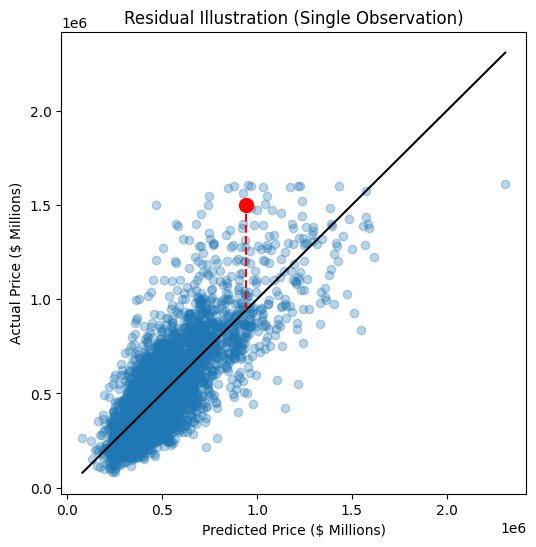

Residual (Actual - Predicted): $557,095


In [112]:
# --------------------------------------------------
# Residual Visualization (Single Observation)
# --------------------------------------------------

# Use converted values from log model
y_true = np.array(y_test_price)
y_pred = np.array(y_test_pred_price)

# Select a reproducible random observation
np.random.seed(1)
idx = np.random.randint(len(y_true))

# Create plot
plt.figure(figsize=(6, 6))

# Scatter: predicted vs actual
plt.scatter(y_pred, y_true, alpha=0.3)

# Highlight selected observation
plt.scatter(y_pred[idx], y_true[idx], color="red", s=100)

# Reference line (perfect prediction: y = x)
plt.plot(
    [y_pred.min(), y_pred.max()],
    [y_pred.min(), y_pred.max()],
    linestyle="-",
    color="black"
)

# Residual line (vertical distance)
plt.plot(
    [y_pred[idx], y_pred[idx]],
    [y_pred[idx], y_true[idx]],
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price ($ Millions)")
plt.ylabel("Actual Price ($ Millions)")
plt.title("Residual Illustration (Single Observation)")

plt.show()

# Compute and display residual
residual = y_true[idx] - y_pred[idx]
print(f"Residual (Actual - Predicted): ${residual:,.0f}")

The residuals appear to be reasonably centered around zero, suggesting that the model does not exhibit systematic over- or under-prediction. While some dispersion increases at higher price levels, this is expected given the greater variability in high-value properties.

Although overall model error is summarized using aggregate metrics such as RMSE, individual prediction errors vary across the price distribution. In particular, higher-priced homes tend to exhibit larger absolute residuals, reflecting increased variability rather than systematic bias.

Overall, the residual pattern indicates that the model captures the primary structure of the data while maintaining acceptable predictive accuracy across the observed price range.

## Conclusion
<a id="conclusion"></a>

This analysis developed a linear regression model for housing price prediction using a structured and iterative modeling approach. Key decisions included applying a log transformation to address skewness, introducing nonlinear terms to capture lifecycle effects, and refining predictor selection based on both statistical evidence and predictive performance.

The final model balances accuracy and interpretability, achieving strong out-of-sample performance while maintaining a clear and explainable structure. Additional modeling approaches, including stepwise regression and one-hot encoding, were explored and provided modest performance improvements, but were not adopted due to increased complexity and reduced interpretability.

Overall, the results demonstrate that a carefully specified linear model can effectively capture the primary drivers of housing prices, while emphasizing the importance of model simplicity, stability, and real-world interpretability in applied settings.
